# **Loading and Sampling Trajectory Data**

## Getting started

Real-world mobility files vary widely in structure and formatting:
- e.g. **Timestamps** may be **UNIX** integers or **ISO-formatted strings**
- May have **timezones**, e.g. -05:00, Z, (GMT+01), -3600
- Coordinates might be **projected** or **geographical**
- Files may be a flat **CSV**, or **partitioned Parquets**, local or **in S3**.

`nomad.io` is here to help.

In [1]:
from nomad.io import base as loader

## **Typical processing**. an example with `pandas`, `geopandas`

Perform preliminary analysis of the data in (`gc-data.csv`).
- **Load** trajectory and geometry data.
- **Plot the data of a user**
- Create **a heatmap** of ping **hotspots**.
- Analyze **gaps** in the user's signals.

In [2]:
import pandas as pd
import geopandas as gpd

df = pd.read_csv("../../tutorials/IC2S2-2025/IC2S2-2025/gc_data.csv")
city = gpd.read_file("../../tutorials/IC2S2-2025/IC2S2-2025/garden_city.geojson")

df.head()

,identifier,device_lon,device_lat,unix_timestamp,local_datetime,date,ha
0,cocky_stallman,-38.318802,36.669894,1704114435,2024-01-01 09:07:15-04:00,2024-01-01,8.492856
1,cocky_stallman,-38.318765,36.669905,1704114753,2024-01-01 09:12:33-04:00,2024-01-01,11.336772
2,cocky_stallman,-38.318627,36.669856,1704114792,2024-01-01 09:13:12-04:00,2024-01-01,18.436612
3,cocky_stallman,-38.318661,36.669920,1704114989,2024-01-01 09:16:29-04:00,2024-01-01,27.370737
4,cocky_stallman,-38.318602,36.669823,1704115195,2024-01-01 09:19:55-04:00,2024-01-01,12.506606


In [ ]:
import h3
from shapely import Polygon
import matplotlib.pyplot as plt

# H3 cell to polygon
def h3_cell_to_polygon(cell):
    coords = h3.cell_to_boundary(cell)
    lat, lon = zip(*coords)
    return Polygon(zip(lon, lat))

# Max gap in minutes
def get_max_gap_minutes(times):
    shifted_times = times.shift(1, fill_value=0) # shift gives previous value
    gaps = (times.iloc[1:] - shifted_times.iloc[1:])//60 # gaps in minutes
    return gaps.max()

## `nomad.io`
`nomad.io.base.from_file` is basically a `pandas` / `pyarrow` wrapper and **partition folders** can be read as columns (Hive).

Don't read partitioned data with a for loop! `nomad`'s `from_file` wraps `PyArrow`'s file readers maintaning the same signature.

In [5]:
# For the partitioned dataset
traj_cols = {"user_id": "user_id",
             "timestamp": "timestamp",
             "latitude": "latitude",
             "longitude": "longitude",
             "datetime": "datetime",
             "date": "date"}

file_path = "../../tutorials/IC2S2-2025/IC2S2-2025/gc_data/" # partitioned


df = loader.from_file(file_path, format="csv", traj_cols=traj_cols, parse_dates=True)
print(df.dtypes)

user_id              object
longitude           float64
latitude            float64
timestamp             Int64
datetime     datetime64[ns]
ha                  float64
date                 object
tz_offset             Int64
dtype: object


In [6]:
## Compute all three statistics
from nomad.filters import to_tessellation

user_df = loader.sample_from_file(
    file_path, format="csv", users=["cocky_stallman"],
    filters=("date", "==", "2024-01-04"), traj_cols=traj_cols) # filter on read

# Pings per cell geodataframe
df["cell"] = to_tessellation(df, index="h3", res=12, traj_cols=traj_cols)

pings_per_cell = df.groupby('cell').agg(pings=(traj_cols['timestamp'], 'count')).reset_index()
h3_gdf = gpd.GeoDataFrame(pings_per_cell, geometry=pings_per_cell['cell'].apply(h3_cell_to_polygon))
h3_gdf = h3_gdf.loc[h3_gdf.pings>1000]

# Maximum gap for each user
max_gap = df.groupby(traj_cols['user_id'])[traj_cols['timestamp']].apply(get_max_gap_minutes)

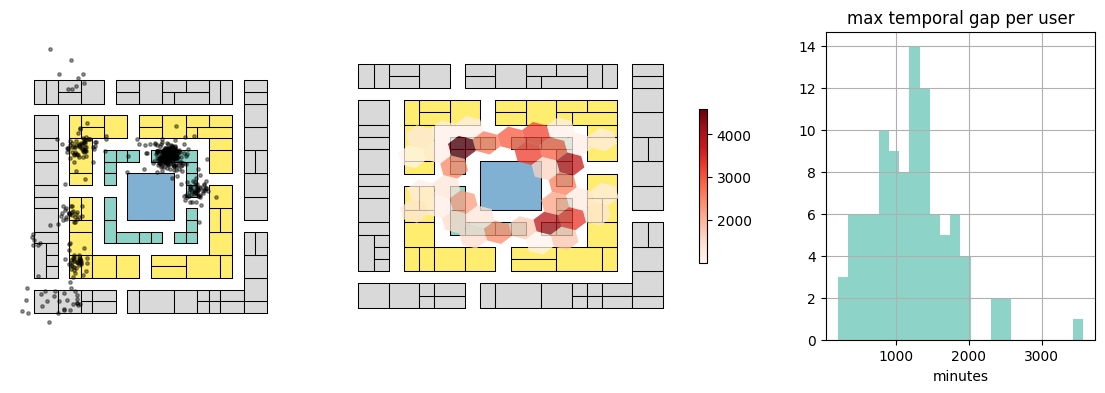

In [7]:
from nomad.stop_detection.viz import plot_pings
## Plotting
fig, (ax1, ax2, ax3) = plt.subplots(figsize=(14,4), ncols=3, width_ratios=[4.5, 7, 4.5])

# trajectory of a single user
city.plot(ax=ax1, column='type', edgecolor='black', linewidth=0.75, cmap='Set3')
plot_pings(user_df, ax=ax1, point_color='black', radius='ha', s=6, alpha=0.4, traj_cols=traj_cols)
ax1.set_axis_off()
# heatmap
city.plot(ax=ax2, column='type', edgecolor='black', linewidth=0.75, cmap='Set3')
h3_gdf.plot(column=h3_gdf.pings, cmap='Reds', alpha=0.75, ax=ax2, legend=True, legend_kwds={'shrink': 0.5})
ax2.set_axis_off()
# gaps
max_gap.hist(ax=ax3, bins=24, color='#8dd3c7')
ax3.set_xlabel('minutes')
ax3.set_title('max temporal gap per user')

plt.show()